In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['TotalCharges'].value_counts().head(20)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
19.45     6
20.3      5
20.45     5
19.85     4
69.9      4
20.4      4
70.6      4
19.2      4
69.65     4
44        4
Name: count, dtype: int64

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [14]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'Contract', 'Churn']]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


In [15]:
categorical_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [16]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
churn_counts = df['Churn'].value_counts()

churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


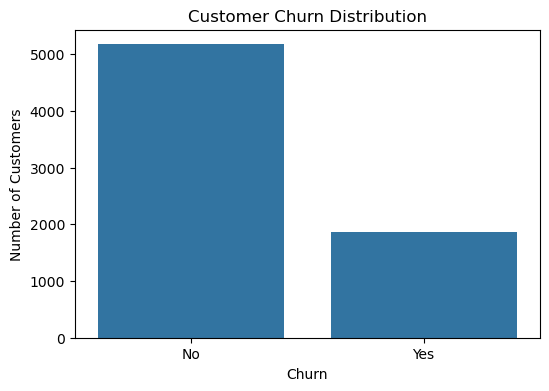

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [20]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [21]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [22]:
contract_churn_rate = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

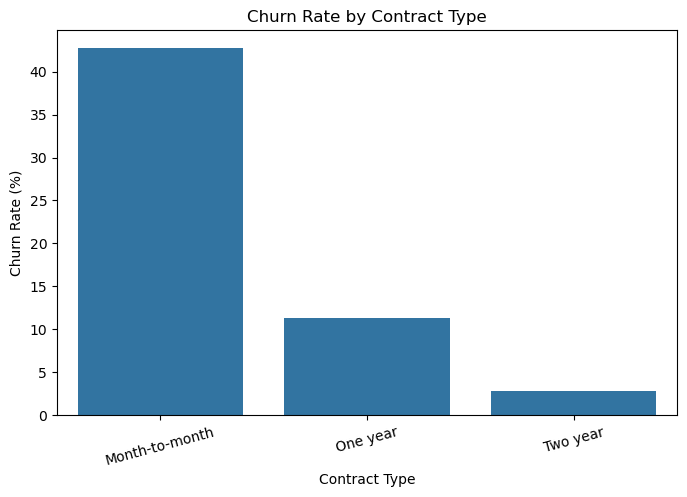

In [28]:

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=15)

plt.show()

In [36]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'])
df['TenureGroup'].value_counts()

TenureGroup
49-72 Months    2239
0-12 Months     2186
25-48 Months    1594
13-24 Months    1024
Name: count, dtype: int64

In [38]:
tenure_churn_rate = (df.groupby('TenureGroup', observed=False)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100))
tenure_churn_rate

TenureGroup
0-12 Months     47.438243
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn, dtype: float64

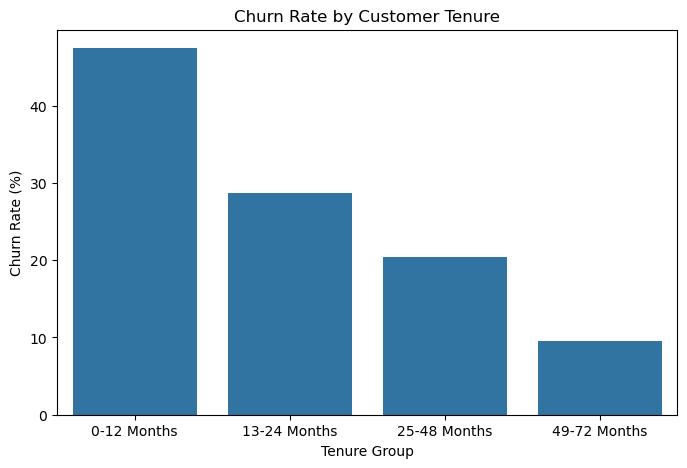

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.show()

In [40]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [41]:
df['ChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 100, 120],
    labels=['Low (0-35)', 'Medium (36-70)', 'High (71-100)', 'Very High (101-120)'])

In [42]:
charge_churn_rate = (
    df.groupby('ChargeGroup', observed=False)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100))

charge_churn_rate

ChargeGroup
Low (0-35)             10.893372
Medium (36-70)         23.942029
High (71-100)          37.821708
Very High (101-120)    28.048780
Name: Churn, dtype: float64

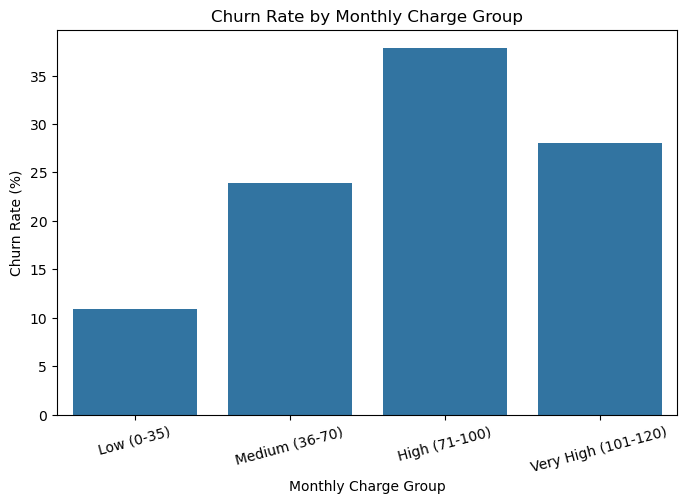

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=charge_churn_rate.index,
    y=charge_churn_rate.values)

plt.title('Churn Rate by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=15)

plt.show()

In [44]:
payment_churn_rate = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

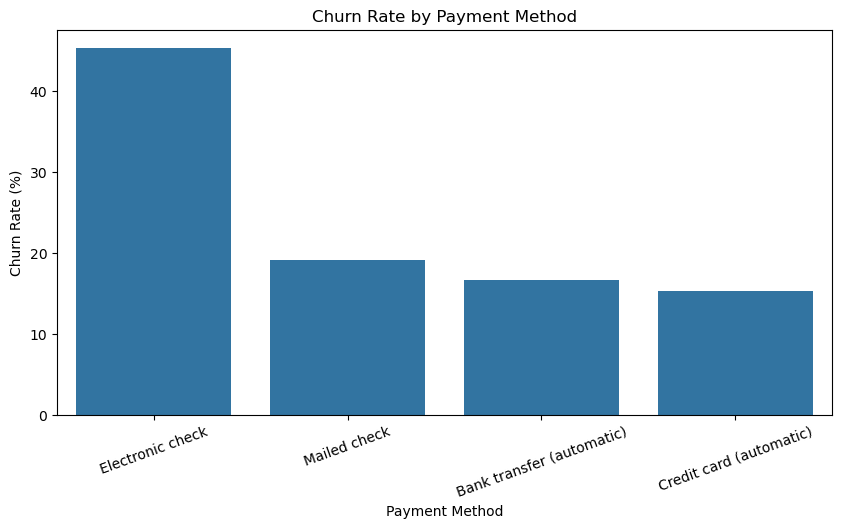

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=20)

plt.show()

In [46]:
internet_churn_rate = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False))

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

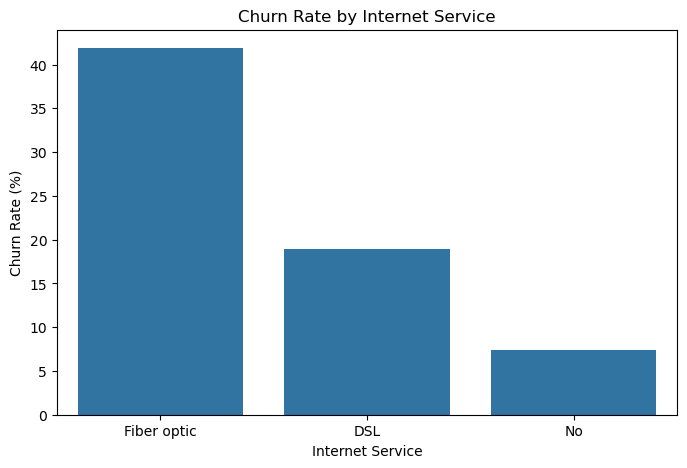

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.show()

In [48]:
techsupport_churn_rate = (
    df.groupby('TechSupport')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

techsupport_churn_rate

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64

In [49]:
security_churn_rate = (
    df.groupby('OnlineSecurity')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

security_churn_rate

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

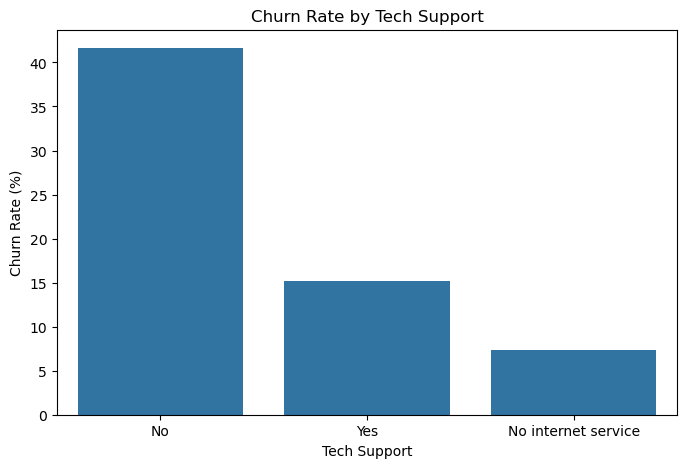

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=techsupport_churn_rate.index,
    y=techsupport_churn_rate.values
)

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')

plt.show()

In [51]:
demographic_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

for column in demographic_columns:
    print(f"\nChurn Rate by {column}:")
    
    result = (
        df.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(result)


Churn Rate by gender:
gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

Churn Rate by SeniorCitizen:
SeniorCitizen
1    41.681261
0    23.606168
Name: Churn, dtype: float64

Churn Rate by Partner:
Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

Churn Rate by Dependents:
Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64


In [52]:
service_columns = [
    'MultipleLines',
    'OnlineBackup',
    'DeviceProtection',
    'StreamingTV',
    'StreamingMovies'
]

for column in service_columns:
    print(f"\nChurn Rate by {column}:")
    
    result = (
        df.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(result)


Churn Rate by MultipleLines:
MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Churn, dtype: float64

Churn Rate by OnlineBackup:
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Churn, dtype: float64

Churn Rate by DeviceProtection:
DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Churn, dtype: float64

Churn Rate by StreamingTV:
StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Churn, dtype: float64

Churn Rate by StreamingMovies:
StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Churn, dtype: float64


In [53]:
contract_tenure_churn = (
    df.groupby(['Contract', 'TenureGroup'])['Churn']
    .agg(Customers='count',ChurnRate=lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .sort_values('ChurnRate', ascending=False))

contract_tenure_churn

C:\Users\Nidhi Jamgade\AppData\Local\Temp\ipykernel_31776\3918993340.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Contract', 'TenureGroup'])['Churn']


Customers  ChurnRate
Contract       TenureGroup                       
Month-to-month 0-12 Months        1994      51.35
               13-24 Months        737      37.72
               25-48 Months        802      32.92
               49-72 Months        342      26.02
One year       49-72 Months        634      12.93
               25-48 Months        518      10.62
               0-12 Months         124      10.48
               13-24 Months        197       8.12
Two year       49-72 Months       1263       3.33
               25-48 Months        274       2.19
               0-12 Months          68       0.00
               13-24 Months         90       0.00

In [54]:
contract_payment_churn = (
    df.groupby(['Contract', 'PaymentMethod'])['Churn']
    .agg(
        Customers='count',
        ChurnRate=lambda x: (x == 'Yes').mean() * 100
    )
    .round(2)
    .sort_values('ChurnRate', ascending=False)
)

contract_payment_churn

Customers  ChurnRate
Contract       PaymentMethod                                  
Month-to-month Electronic check                1850      53.73
               Bank transfer (automatic)        589      34.13
               Credit card (automatic)          543      32.78
               Mailed check                     893      31.58
One year       Electronic check                 347      18.44
               Credit card (automatic)          398      10.30
               Bank transfer (automatic)        391       9.72
Two year       Electronic check                 168       7.74
One year       Mailed check                     337       6.82
Two year       Bank transfer (automatic)        564       3.37
               Credit card (automatic)          581       2.24
               Mailed check                     382       0.79

In [57]:
risk_analysis = df[
    [
        'customerID',
        'Contract',
        'TenureGroup',
        'PaymentMethod',
        'InternetService',
        'TechSupport',
        'OnlineSecurity',
        'MonthlyCharges',
        'Churn'
    ]
].copy()
risk_analysis.head()

,customerID,Contract,TenureGroup,PaymentMethod,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,Churn
0,7590-VHVEG,Month-to-month,0-12 Months,Electronic check,DSL,No,No,29.85,No
1,5575-GNVDE,One year,25-48 Months,Mailed check,DSL,No,Yes,56.95,No
2,3668-QPYBK,Month-to-month,0-12 Months,Mailed check,DSL,No,Yes,53.85,Yes
3,7795-CFOCW,One year,25-48 Months,Bank transfer (automatic),DSL,Yes,Yes,42.30,No
4,9237-HQITU,Month-to-month,0-12 Months,Electronic check,Fiber optic,No,No,70.70,Yes


In [58]:
risk_analysis['RiskFactorCount'] = (
    (risk_analysis['Contract'] == 'Month-to-month').astype(int)
    + (risk_analysis['TenureGroup'] == '0-12 Months').astype(int)
    + (risk_analysis['PaymentMethod'] == 'Electronic check').astype(int)
    + (risk_analysis['InternetService'] == 'Fiber optic').astype(int)
    + (risk_analysis['TechSupport'] == 'No').astype(int)
    + (risk_analysis['OnlineSecurity'] == 'No').astype(int)
    + (risk_analysis['MonthlyCharges'] > 70).astype(int))

In [59]:
risk_analysis['RiskFactorCount'].value_counts().sort_index()

RiskFactorCount
0    1073
1     840
2    1147
3     890
4     937
5     896
6     776
7     484
Name: count, dtype: int64

In [60]:
risk_factor_churn = (
    risk_analysis.groupby('RiskFactorCount')['Churn']
    .agg(
        Customers='count',
        ChurnRate=lambda x: (x == 'Yes').mean() * 100
    )
    .round(2)
)

risk_factor_churn

,Customers,ChurnRate
RiskFactorCount,,
0,1073,1.21
1,840,5.24
2,1147,13.95
3,890,16.52
4,937,29.88
5,896,44.64
6,776,60.05
7,484,74.17


In [61]:
risk_analysis['RiskSegment'] = pd.cut(
    risk_analysis['RiskFactorCount'],
    bins=[-1, 2, 4, 7],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

In [62]:
risk_segment_summary = (
    risk_analysis.groupby('RiskSegment', observed=False)['Churn']
    .agg(
        Customers='count',
        ChurnRate=lambda x: (x == 'Yes').mean() * 100)
    .round(2))

risk_segment_summary

,Customers,ChurnRate
RiskSegment,,
Low Risk,3060,7.09
Medium Risk,1827,23.37
High Risk,2156,56.82


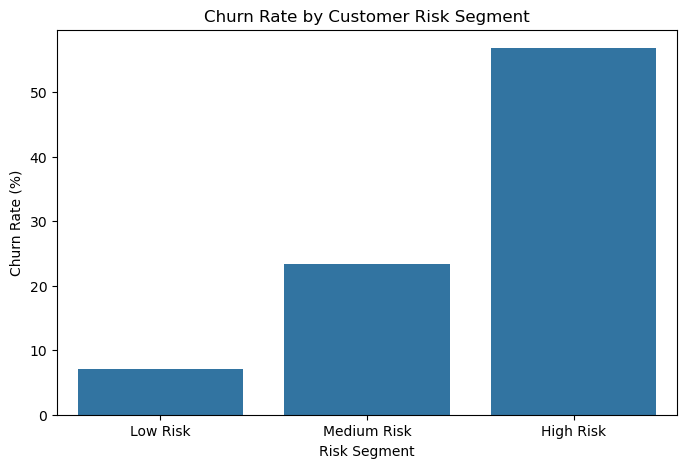

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_segment_summary.reset_index(),
    x='RiskSegment',
    y='ChurnRate'
)

plt.title('Churn Rate by Customer Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

In [64]:
high_risk = risk_analysis[
    risk_analysis['RiskSegment'] == 'High Risk'
]

high_risk.head()

,customerID,Contract,TenureGroup,PaymentMethod,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,Churn,RiskFactorCount,RiskSegment
0,7590-VHVEG,Month-to-month,0-12 Months,Electronic check,DSL,No,No,29.85,No,5,High Risk
4,9237-HQITU,Month-to-month,0-12 Months,Electronic check,Fiber optic,No,No,70.70,Yes,7,High Risk
5,9305-CDSKC,Month-to-month,0-12 Months,Electronic check,Fiber optic,No,No,99.65,Yes,7,High Risk
6,1452-KIOVK,Month-to-month,13-24 Months,Credit card (automatic),Fiber optic,No,No,89.10,No,5,High Risk
8,7892-POOKP,Month-to-month,25-48 Months,Electronic check,Fiber optic,Yes,No,104.80,Yes,5,High Risk


In [65]:
print("High-risk customers:", len(high_risk))
print("\nContract:")
print(high_risk['Contract'].value_counts())

print("\nPayment Method:")
print(high_risk['PaymentMethod'].value_counts())

print("\nInternet Service:")
print(high_risk['InternetService'].value_counts())

print("\nTech Support:")
print(high_risk['TechSupport'].value_counts())

print("\nOnline Security:")
print(high_risk['OnlineSecurity'].value_counts())

High-risk customers: 2156

Contract:
Contract
Month-to-month    2057
One year            81
Two year            18
Name: count, dtype: int64

Payment Method:
PaymentMethod
Electronic check             1578
Bank transfer (automatic)     220
Credit card (automatic)       194
Mailed check                  164
Name: count, dtype: int64

Internet Service:
InternetService
Fiber optic    1952
DSL             204
Name: count, dtype: int64

Tech Support:
TechSupport
No     1977
Yes     179
Name: count, dtype: int64

Online Security:
OnlineSecurity
No     1976
Yes     180
Name: count, dtype: int64


In [67]:
clean_df=df.copy()

In [68]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [70]:
clean_df['TenureGroup'] = pd.cut(clean_df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'])
clean_df['ChargeGroup'] = pd.cut(
    clean_df['MonthlyCharges'],
    bins=[0, 35, 70, 100, 120],
    labels=['Low (0-35)', 'Medium (36-70)', 'High (71-100)', 'Very High (101-120)'])

In [71]:
clean_df['RiskFactorCount'] = (
    (clean_df['Contract'] == 'Month-to-month').astype(int)
    + (clean_df['TenureGroup'] == '0-12 Months').astype(int)
    + (clean_df['PaymentMethod'] == 'Electronic check').astype(int)
    + (clean_df['InternetService'] == 'Fiber optic').astype(int)
    + (clean_df['TechSupport'] == 'No').astype(int)
    + (clean_df['OnlineSecurity'] == 'No').astype(int)
    + (clean_df['MonthlyCharges'] > 70).astype(int)
)

In [72]:
clean_df['RiskSegment'] = pd.cut(
    clean_df['RiskFactorCount'],
    bins=[-1, 2, 4, 7],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

In [73]:
clean_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
TenureGroup          0
ChargeGroup          0
RiskFactorCount      0
RiskSegment          0
dtype: int64

In [74]:
clean_df[['TotalCharges', 'TenureGroup', 'ChargeGroup',
          'RiskFactorCount', 'RiskSegment']].head()

,TotalCharges,TenureGroup,ChargeGroup,RiskFactorCount,RiskSegment
0,29.85,0-12 Months,Low (0-35),5,High Risk
1,1889.50,25-48 Months,Medium (36-70),1,Low Risk
2,108.15,0-12 Months,Medium (36-70),3,Medium Risk
3,1840.75,25-48 Months,Medium (36-70),0,Low Risk
4,151.65,0-12 Months,High (71-100),7,High Risk


In [76]:
clean_df.to_csv(
    "Telco_Customer_Churn_Cleaned.csv",
    index=False
)

In [77]:
import os
os.path.exists("Telco_Customer_Churn_Cleaned.csv")

True

In [78]:
os.path.getsize("Telco_Customer_Churn_Cleaned.csv")

1253991

In [80]:
import os
os.path.abspath("Telco_Customer_Churn_Cleaned.csv")

'C:\\Users\\Nidhi Jamgade\\Downloads\\Customer Churn Analysis Data\\Telco_Customer_Churn_Cleaned.csv'

In [83]:
sql_file = "customer_churn_insert.sql"

with open(sql_file, "w", encoding="utf-8") as f:
    for _, row in clean_df.iterrows():
        values = []

        for value in row:
            if pd.isna(value):
                values.append("null")
            elif isinstance(value, str):
                value = value.replace("'", "''")
                values.append(f"'{value}'")
            else:
                values.append(str(value))

        f.write(
            "insert into customer_churn values ("
            + ", ".join(values)
            + ");\n"
        )

print("SQL file created successfully.")

SQL file created successfully.
